In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

### `Q.1`. Given a normal distribution with mean as 50 and deviation as 10, answer below questions

(X ~ N(5O, 10) ):

    a. what are the values of the mean and standard deviation?
    
    b. What value of x has a z-score of 1.4?

    c. What is the Z-score that corresponds to x = 30?

    d. What is the difference between positive and negative z values?

### `Q.2:`The average test score in a certain statistics class was 74 with a standard deviation of 8. There are 2000 students in this class. Use the emperical rule to answer the following questions:
    (a) What percentage of students scored less than 58?
    (b) What is the probability that a student score between 66 and 82 on the exam?
    (c) How many students scored at most 90?
    (d) What percentage of students scored at least 66?
    (e) How many students scored more than 98 on the test?


In [ ]:
sample_mean = 74
sample_std = 8
n = 2000

# draw the normal distribution of the curve

from scipy.stats import norm
dist = norm(sample_mean,sample_std)


In [ ]:
from numpy.random import normal
sample1 = normal(loc = 74,scale = 8,size = 2000)


array([66.98969936, 78.07016218, 68.91443769, ..., 74.24262382,
       73.82684675, 65.99234246], shape=(2000,))

In [9]:
sample1.mean()

np.float64(73.91993464482611)

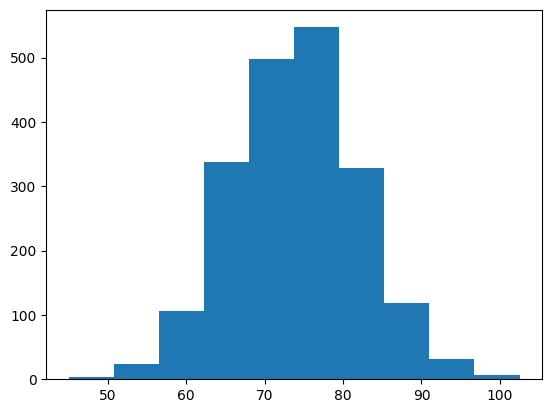

In [11]:
plt.hist(sample1)
plt.show()

In [13]:
#draw the distribution using kde 

values = np.linspace(sample1.min(),sample1.max(),100)
probabilities = [dist.pdf(value) for value in values]

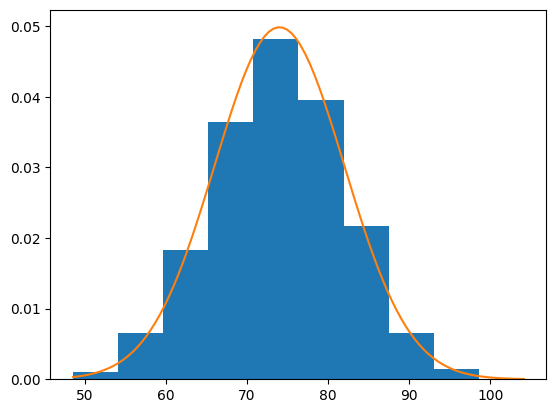

In [14]:
plt.hist(sample1,bins=10,density = True)
plt.plot(values,probabilities)

In [ ]:
#(1) (a) What percentage of students scored less than 58?

100*dist.cdf(58)

np.float64(2.27501319481792)

In [ ]:
#(2) What is the probability that a student score between 66 and 82 on the exam?

100*(dist.cdf(82) - dist.cdf(66))

np.float64(68.26894921370858)

In [ ]:
#(3) How many students scored at most 90?

# unique, counts = np.unique(sample1, return_counts=True)

# dict(zip(unique, counts))

100*(dist.cdf(90))

np.float64(97.72498680518208)

In [ ]:
#(4) What percentage of students scored at least 66?

100*(1 - dist.cdf(65.9999999999))

np.float64(84.13447460715676)

In [65]:
#(5) How many students scored more than 98 on the test?

100*(1-dist.cdf(98))

np.float64(0.13498980316301035)

### `Q-3:` Normally distributed IQ scores have a mean of 100 and a standard deviation of 15. Use the standard z-table to answer the following questions:

What is the probability of randomly selecting someone with an IQ score that is

    (a) less than 80?
    (b) greater than 136?
    (c) between 95 and 110?
    (d) What IQ score corresponds to the 90th percentile?
    (e) The middle 30% of IQs fall between what two values?

In [ ]:
sample_mean = 100
sample_std = 15

#(1) - Less than 80 

z = (80-100)/15
# 9.176%

-1.3333333333333333

In [34]:
#(2) greater than 136

z = (136-100)/15
z

100*(1 - 0.99180)


0.8199999999999985

In [37]:
#3 Between 95 and 110

z1 = (95-100)/15
z2 = (110-100)/15

In [ ]:
100*(0.74537 - 0.37070) 

37.467

In [ ]:
#4 What IQ corresponds to the 90th percentile
1.29*15 + 100 = 119.35

SyntaxError: cannot assign to expression here. Maybe you meant '==' instead of '='? (3714121029.py, line 4)

In [ ]:
#The middle 30% of IQ falls between which two value
#lets find the probablity at point 35% and 65%

-0.36*15 + 100 == 94.6
0.39*15 + 100 == 105.85


105.85

###`Q-4`: Wine data
```
# Load dataset
import pandas as pd
from sklearn.datasets import load_wine

# load the wine dataset
data = load_wine()
df = pd.DataFrame(data.data, columns=data.feature_names)
df["target"] = data.target

```
Consider this "wine" dataset which can be loaded using above code. It has 13 numerical features and a target column with 3 class: 0, 1, 2.


* **Which feature is the best predictor of the wine class in the wine dataset?** (Using pdf plot)

* **Which two combination of features from below listed features are best for wine classification?** (2D pdf plot)
    * Proline
    * Flavanoids
    * Color intensity
    * OD280/OD315 of diluted wines
    * Alcohol

In [51]:
from sklearn.datasets import load_wine

data = load_wine()
df = pd.DataFrame(data.data, columns=data.feature_names)
df["target"] = data.target
df


,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0,0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0,0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0,0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0,0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
173,13.71,5.65,2.45,20.5,95.0,1.68,0.61,0.52,1.06,7.70,0.64,1.74,740.0,2
174,13.40,3.91,2.48,23.0,102.0,1.80,0.75,0.43,1.41,7.30,0.70,1.56,750.0,2
175,13.27,4.28,2.26,20.0,120.0,1.59,0.69,0.43,1.35,10.20,0.59,1.56,835.0,2
176,13.17,2.59,2.37,20.0,120.0,1.65,0.68,0.53,1.46,9.30,0.60,1.62,840.0,2


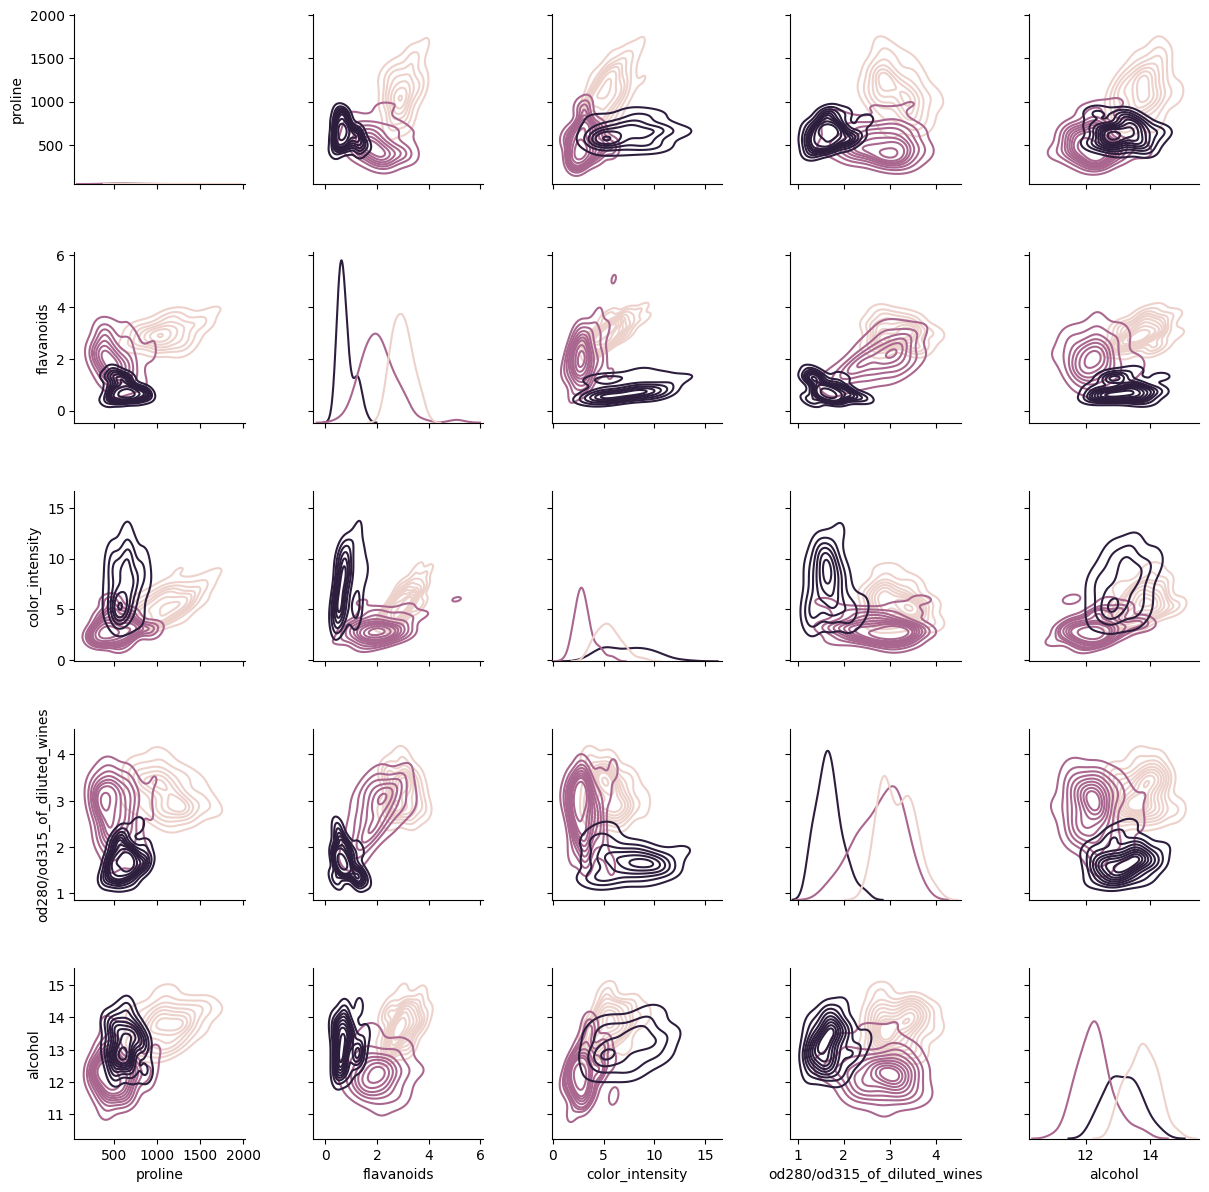

In [69]:
g = sns.PairGrid(data=df[['proline','flavanoids','color_intensity','od280/od315_of_diluted_wines','alcohol','target']],hue='target')
g.map_diag(sns.kdeplot)
g.map_offdiag(sns.kdeplot)
plt.subplots_adjust(top=0.95, bottom=0.05, left=0.05, right=0.95, hspace=0.4, wspace=0.4)

plt.show()


# flavanoids -- alcohol
# Proline -- Flavanoids
# Flavanoids -- Alcohol
# Color Intensity -- Alcohol
# od280/od315_of_diluted_wines -- Alcohol


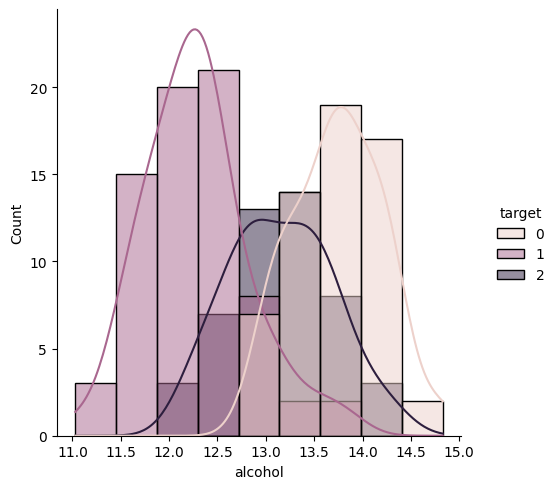

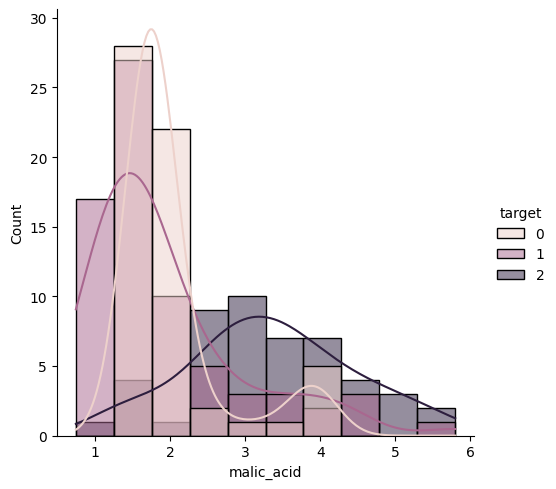

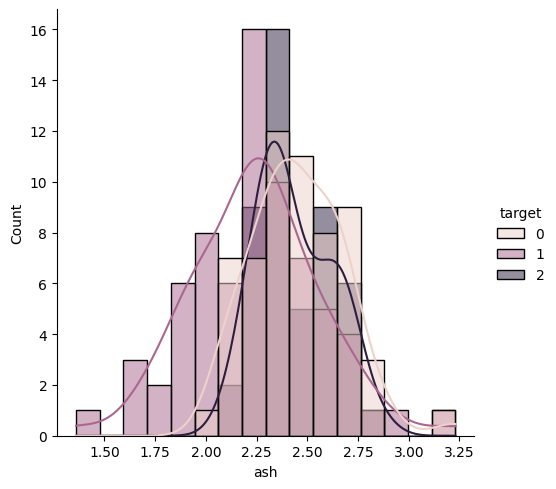

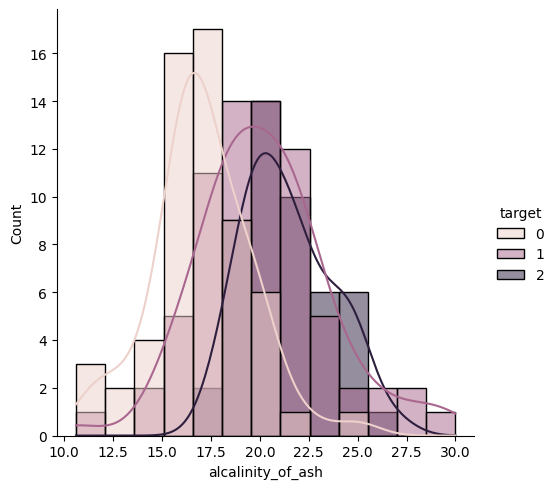

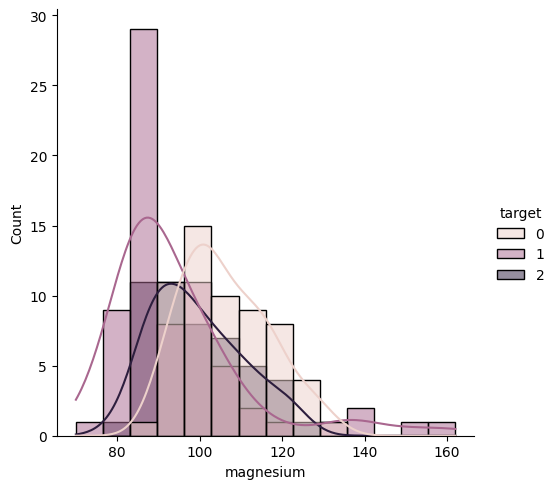

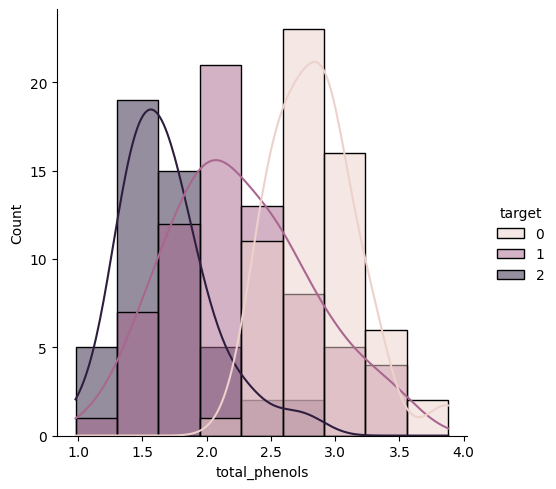

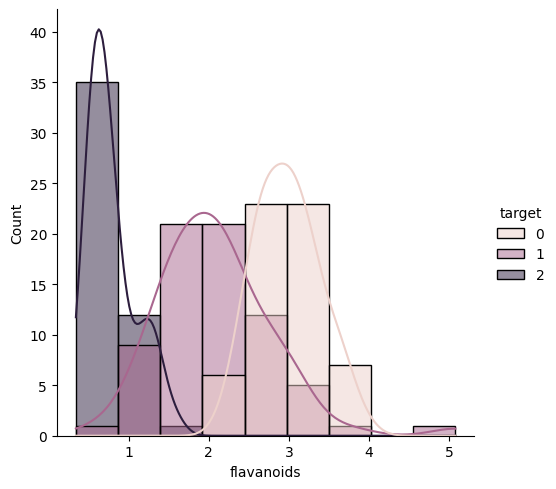

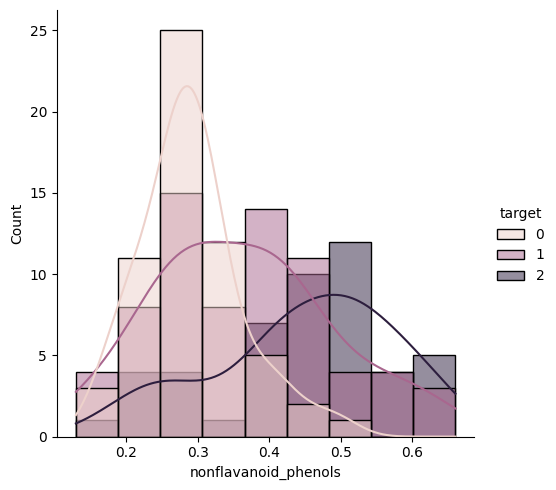

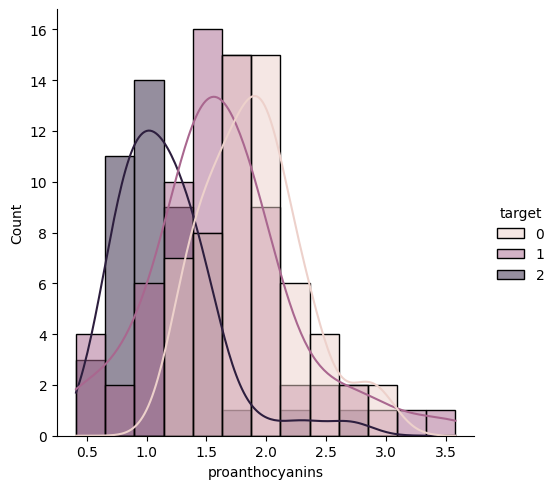

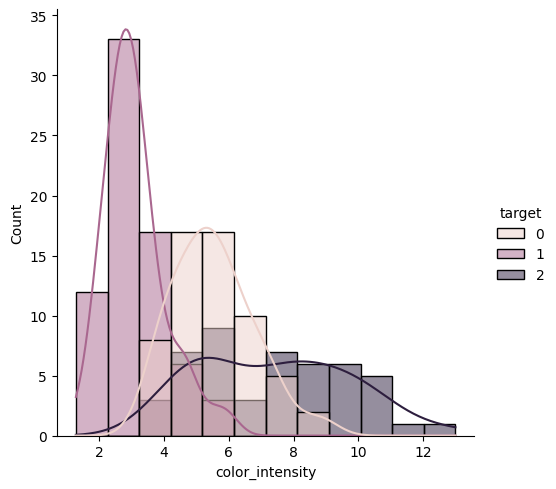

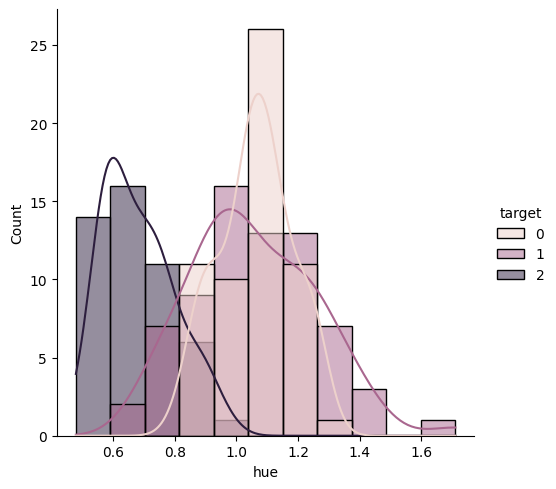

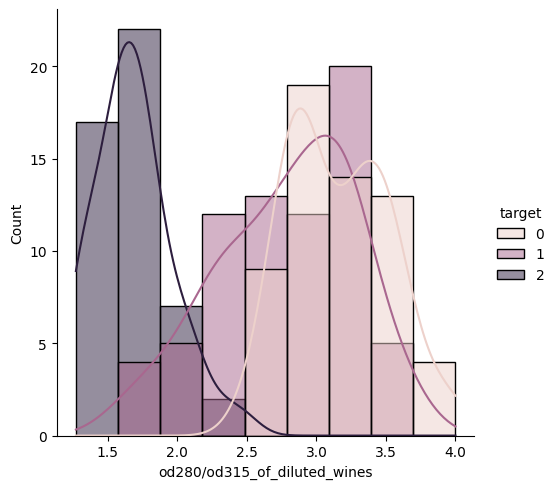

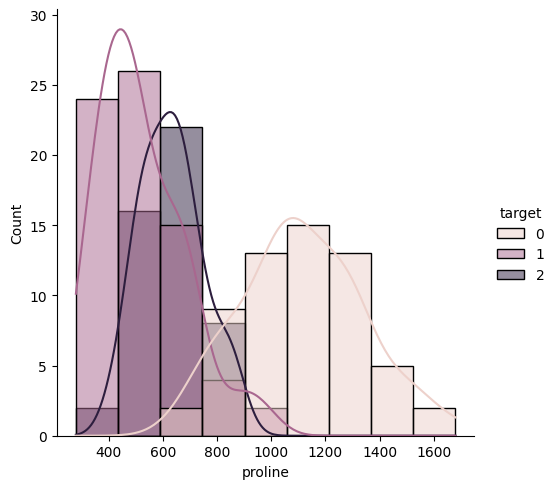

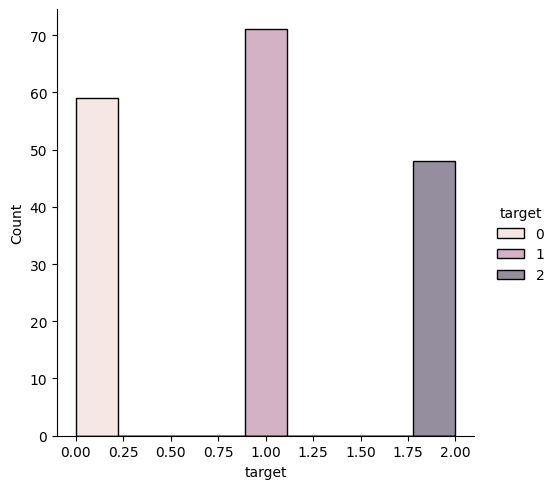

In [55]:
#Which feature is the best predicter of the wine target classification 
sns.set_color_codes(palette='deep')
for item in df.columns:
    sns.displot(data=df,x = item,hue = 'target',kind='hist',kde= True)
